Thomas Sears

9-27-26

Lab 5: Orbits

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A - A Single Orbit With Velocity Verlet

Description: Simulates the orbital system of two point masses (a star and a smaller mass) using the velocity verlet method. Also calculates the total energy and angular momentum of the system to check if the verlet method is sufficient for simulating this system.

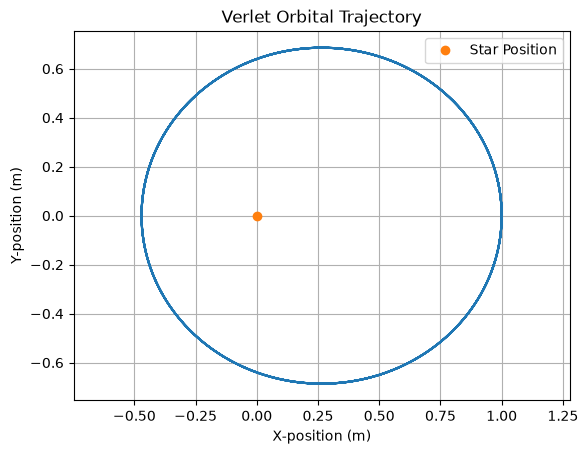

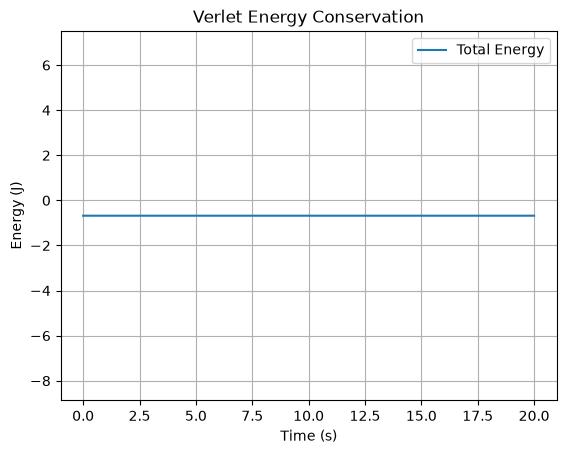

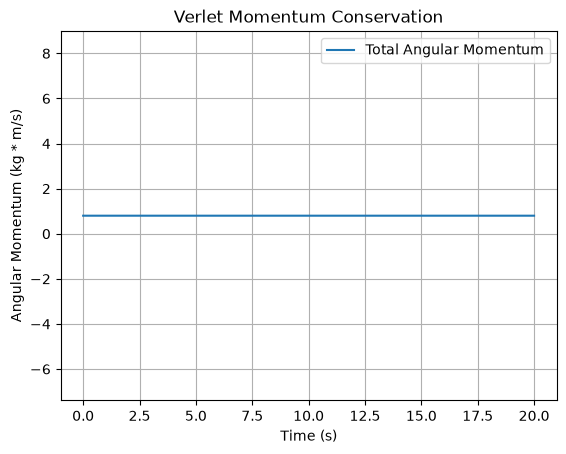

In [2]:
#Constants
G = 1.0
M = 1.0

def verlet_step(r, v, a, dt, accel_func):
    r_new = r + v * dt + 0.5 * a * dt**2
    a_new = accel_func(r_new)
    v_new = v + 0.5 * (a + a_new) * dt
    return r_new, v_new, a_new

def accel_func(r):
    dist = np.linalg.norm(r)
    a_r = -G*M*r/dist**3
    return a_r

def energy(r, v, G, M, m=1.0):
    ke = 0.5 * m * np.dot(v, v)
    pe = -G * M * m / np.linalg.norm(r)
    return ke + pe

def ang_momentum(r, v, m=1.0):
    return m * (r[0] * v[1] - r[1] * v[0])


#Initial Conditions
r = np.array([1.0, 0.0])
v = np.array([0.0, 0.8])
a = accel_func(r)

dt = 0.001
n_steps = 20000
rs = [r.copy()]
total_e = []
total_ang_momentum = []
for _ in range(n_steps):
    total_e.append(energy(r, v, G, M))
    total_ang_momentum.append(ang_momentum(r, v))
    r, v, a = verlet_step(r, v, a, dt, accel_func)
    rs.append(r.copy())
rs = np.array(rs)
total_e = np.array(total_e)
total_ang_momentum = np.array(total_ang_momentum)

plt.plot(rs[:, 0], rs[:, 1])
plt.plot(0, 0, 'o', label="Star Position")
plt.xlabel("X-position (m)")
plt.ylabel("Y-position (m)")
plt.title("Verlet Orbital Trajectory")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

plt.plot(np.arange(n_steps) * dt, total_e, label="Total Energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Verlet Energy Conservation")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

plt.plot(np.arange(n_steps) * dt, total_ang_momentum, label="Total Angular Momentum")
plt.xlabel("Time (s)")
plt.ylabel("Angular Momentum (kg * m/s)")
plt.title("Verlet Momentum Conservation")
plt.legend()
plt.axis("equal")
plt.grid()
plt.show()

Discussion: The Energy Plot correctly shows a straight line which indicates that the Verlet method is properly conserving energy. This system starts at apoapsis (the furthest point from the star) because the orbiting body is below the initial velocity required, v = [0, 1] that would maintain a perfectly circular orbit. This causes the body to be slowed down enough that the star's gravity pulls it closer to itself giving the elliptical shape.

Part B - The Integrator Showdown

Description : In this section, a comparison is made between the 3 numerical methods we have worked with so far, Euler, Euler-Cromer, and Verlet. This section uses a simulate function that can run either of the 3 methods and then plots their trajectories and also calculates their energy errors, showing why verlet is the best method for this system.

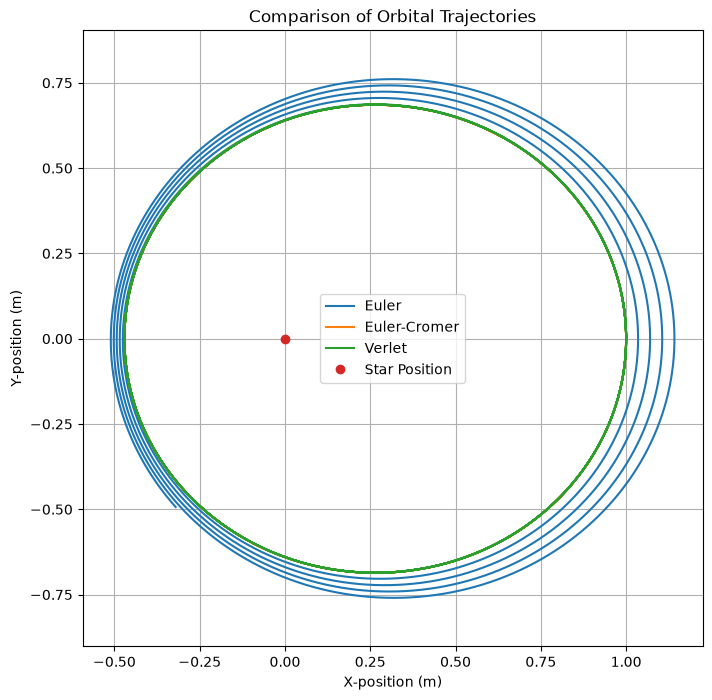

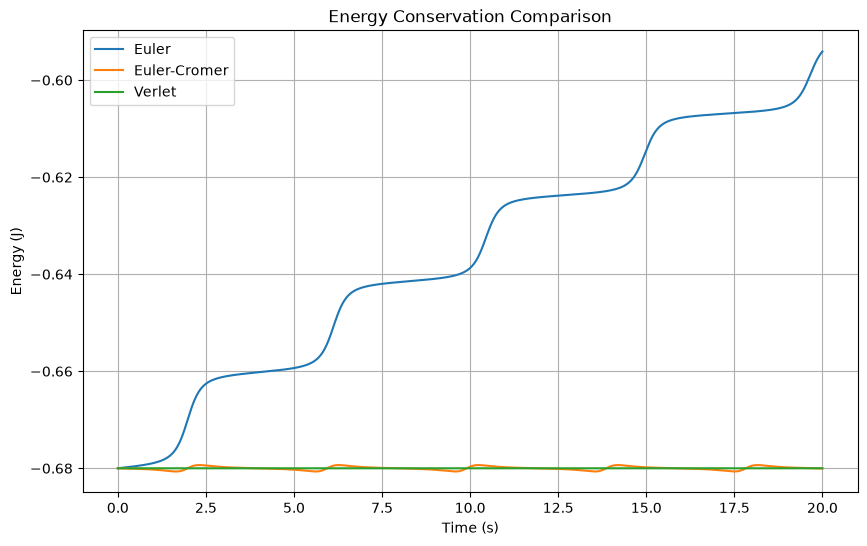

Method          Maximum Fractional Energy Error
Euler            0.1263225419148195
Euler-Cromer     0.0009763462163022773
Verlet           2.1318638648521885e-06


In [3]:
# Compare Euler, Euler-Cromer, and Verlet
def simulate(method, dt, n_steps):
    # Initial Conditions
    r = np.array([1.0, 0.0])
    v = np.array([0.0, 0.8])
    a = accel_func(r)

    rs = [r.copy()]
    total_e = []

    for _ in range(n_steps):
        # Total Energy
        total_e.append(energy(r, v, G, M))

        if method == 'euler':
            r_new = r + v * dt
            v_new = v + a * dt
            a_new = accel_func(r_new)

        elif method == 'euler-cromer':
            v_new = v + a * dt
            r_new = r + v_new * dt
            a_new = accel_func(r_new)

        elif method == 'verlet':
            r_new = r + v * dt + 0.5 * a * dt**2
            a_new = accel_func(r_new)
            v_new = v + 0.5 * (a + a_new) * dt

        r = r_new
        v = v_new
        a = a_new

        rs.append(r.copy())

    rs = np.array(rs)
    total_e = np.array(total_e)

    return rs, total_e


# Parameters
dt = 0.001
n_steps = 20000

# Run all three methods
rs_euler, energy_euler = simulate('euler', dt, n_steps)
rs_ec, energy_ec = simulate('euler-cromer', dt, n_steps)
rs_verlet, energy_verlet = simulate('verlet', dt, n_steps)

time = np.arange(n_steps) * dt

# Initial Energy
E0 = energy_euler[0]

# Energy Error
frac_error_euler = np.max(np.abs((energy_euler - E0) / E0))
frac_error_ec = np.max(np.abs((energy_ec - E0) / E0))
frac_error_verlet = np.max(np.abs((energy_verlet - E0) / E0))


# Plot trajectories
plt.figure(figsize=(8, 8))

plt.plot(rs_euler[:, 0], rs_euler[:, 1], label="Euler")
plt.plot(rs_ec[:, 0], rs_ec[:, 1], label="Euler-Cromer")
plt.plot(rs_verlet[:, 0], rs_verlet[:, 1], label="Verlet")

plt.plot(0, 0, 'o', label="Star Position")

plt.xlabel("X-position (m)")
plt.ylabel("Y-position (m)")
plt.title("Comparison of Orbital Trajectories")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# Plot total energy
plt.figure(figsize=(10, 6))

plt.plot(time, energy_euler, label="Euler")
plt.plot(time, energy_ec, label="Euler-Cromer")
plt.plot(time, energy_verlet, label="Verlet")

plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy Conservation Comparison")
plt.legend()
plt.grid()
plt.show()


# Summary table
print("Method          Maximum Fractional Energy Error")
print("Euler           ", frac_error_euler)
print("Euler-Cromer    ", frac_error_ec)
print("Verlet          ", frac_error_verlet)

Discussion: The Euler method spirals and does not conserve energy because it is not a symplectic integrator meaning it does not keep error bounded like Euler-Cromer or Verlet. This happens because the Euler method updates the position of the orbit before updating the velocity causing it to overestimate both energy and position as time increases. The Verlet method on the other hand, is a symplectic integrator and therefore the error stays bounded and is not allowed to grow like in the Euler method. So, even though Verlet is only second order, it is drastically better than Euler because of its symplectic nature.

Part C - Verify Kepler's Three Laws

Description: This section attempts to verify Kepler's Laws using the Verlet method by calculating the semi-major axis of the orbit, the area swept by the orbit at each time step, and ploting period vs semi-major axis to verify the 3rd Law.

1st Law

Minimum radius = 0.47058912735583197
Maximum radius = 1.0
Semi-major axis = 0.735294563677916


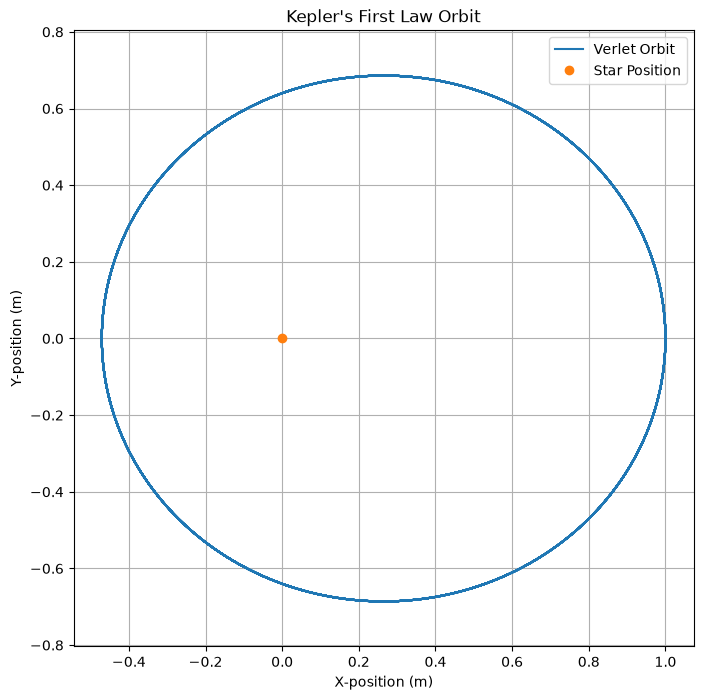

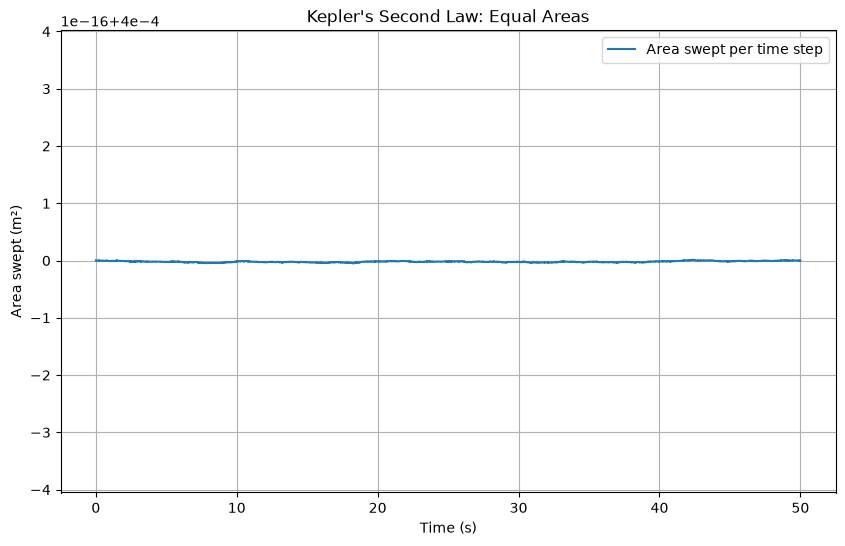

Second Law

Mean area per step = 0.000399999999999998
Max area error = 8.4025668367627e-15

Third Law

v0 = 0.6   a = 0.6097576392954979   T = 2.9917334043007218
v0 = 0.8   a = 0.735294563677916   T = 3.9616153762344988
v0 = 1.0   a = 1.000000249999938   T = 6.283187401589396
v0 = 1.2   a = 1.7857148734435224   T = 14.993327210330783

Measured slope = 39.47841576821994
Expected slope = 39.47841760435743
Fractional difference = 4.650990602303301e-08


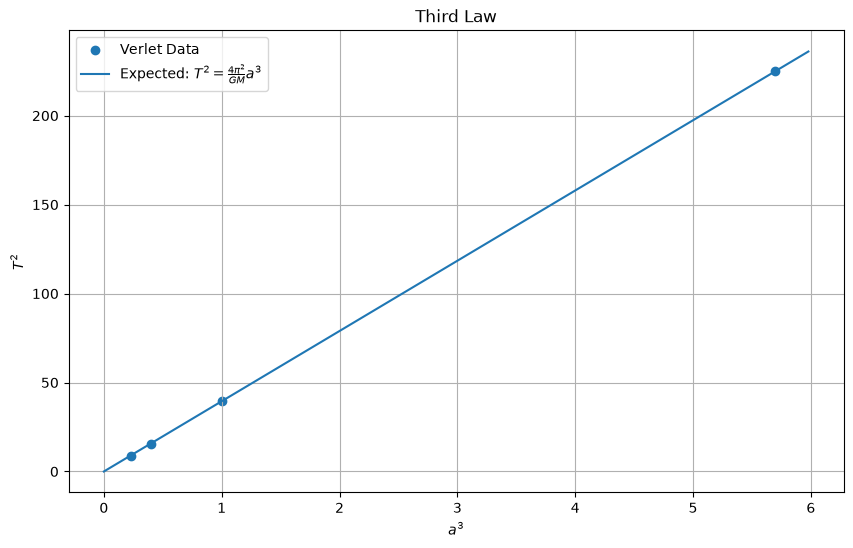

In [4]:
# Verlet simulation
def simulate_verlet(v0, dt, n_steps):

    # Initial Conditions
    r = np.array([1.0, 0.0])
    v = np.array([0.0, v0])
    a = accel_func(r)

    rs = [r.copy()]
    vs = [v.copy()]

    for _ in range(n_steps):
        r_new = r + v * dt + 0.5 * a * dt**2
        a_new = accel_func(r_new)
        v_new = v + 0.5 * (a + a_new) * dt

        r = r_new
        v = v_new
        a = a_new

        rs.append(r.copy())
        vs.append(v.copy())

    rs = np.array(rs)
    vs = np.array(vs)

    return rs, vs

# First Law
dt = 0.001
n_steps = 50000
v0 = 0.8

rs, vs = simulate_verlet(v0, dt, n_steps)

time = np.arange(n_steps + 1) * dt

# Distance from star
radii = np.linalg.norm(rs, axis=1)

# Find a
r_min = np.min(radii)
r_max = np.max(radii)
a = 0.5 * (r_min + r_max)

print("1st Law\n")
print("Minimum radius =", r_min)
print("Maximum radius =", r_max)
print("Semi-major axis =", a)


# Plot orbit
plt.figure(figsize=(8, 8))
plt.plot(rs[:, 0], rs[:, 1], label="Verlet Orbit")
plt.plot(0, 0, 'o', label="Star Position")
plt.xlabel("X-position (m)")
plt.ylabel("Y-position (m)")
plt.title("Kepler's First Law Orbit")
plt.legend()
plt.grid()
plt.axis("equal")
plt.show()


# Second Law
area_swept = 0.5 * np.abs(rs[:, 0] * vs[:, 1] - rs[:, 1] * vs[:, 0]) * dt

plt.figure(figsize=(10, 6))
plt.plot(time, area_swept, label="Area swept per time step")
plt.xlabel("Time (s)")
plt.ylabel("Area swept (m²)")
plt.title("Kepler's Second Law: Equal Areas")
plt.legend()
plt.grid()
plt.show()

# Check if area is constant
area_mean = np.mean(area_swept)
area_error = np.max(np.abs(area_swept - area_mean)) / area_mean

print("Second Law\n")
print("Mean area per step =", area_mean)
print("Max area error =", area_error)

# Third Law
v0_values = [0.6, 0.8, 1.0, 1.2]

dt = 0.001
n_steps = 100000

a_values = []
T_values = []

for v0 in v0_values:

    rs, vs = simulate_verlet(v0, dt, n_steps)

    time = np.arange(n_steps + 1) * dt

    # Distance from star
    radii = np.linalg.norm(rs, axis=1)

    # Find a
    r_min = np.min(radii)
    r_max = np.max(radii)
    a = 0.5 * (r_min + r_max)

    # Find crossings of y = 0 from negative to positive
    crossing_indices = np.where((rs[:-1, 1] < 0) & (rs[1:, 1] >= 0))[0]

    # First positive crossing gives the orbital period
    i = crossing_indices[0]

    # Linear interpolation to estimate crossing time
    y1 = rs[i, 1]
    y2 = rs[i + 1, 1]

    t1 = time[i]
    t2 = time[i + 1]

    t_cross = t1 + (0 - y1) * (t2 - t1) / (y2 - y1)

    T = t_cross

    a_values.append(a)
    T_values.append(T)


a_values = np.array(a_values)
T_values = np.array(T_values)

# Calculate a^3 and T^2
a_cubed = a_values**3
T_squared = T_values**2

# Best-fit slope
slope = np.sum(a_cubed * T_squared) / np.sum(a_cubed**2)

# Expected slope
expected_slope = 4 * np.pi**2 / (G * M)

print("\nThird Law")
print()

for i in range(len(v0_values)):
    print(
        "v0 =", v0_values[i],
        "  a =", a_values[i],
        "  T =", T_values[i]
    )

print()
print("Measured slope =", slope)
print("Expected slope =", expected_slope)
print("Fractional difference =", abs(slope - expected_slope) / expected_slope)


# Plot T^2 vs a^3
plt.figure(figsize=(10, 6))

plt.scatter(a_cubed, T_squared, label="Verlet Data")

# Expected slope through origin
a3_line = np.linspace(0, np.max(a_cubed) * 1.05, 200)
T2_line = expected_slope * a3_line

plt.plot(a3_line, T2_line, label="Expected: $T^2 = \\frac{4\\pi^2}{GM}a^3$")

plt.xlabel("$a^3$")
plt.ylabel("$T^2$")
plt.title("Third Law")
plt.legend()
plt.grid()
plt.show()

Discussion: My calcuated slope is very close to the expected value of 4pi^2 with an error of order ~0.000001. The main sources of error are from the semi-major axis calculation and also a small error from the timestep. Since Verlet is 2nd order, the timestep error is around dt^2 so, using dt = 0.001, the timestep error is very small.

Why 2nd Law is equivalent to angular momentum conservation - Since the rate of area swept is proportional to the angular momentum L, the 2nd Law can be used to verify momentum conservation.